<a href="https://colab.research.google.com/github/Rabiatou08/DI-Bootcamp/blob/main/week3/Day3/Daillychalenges/defi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Défi quotidien : Analyse complète des prix des téléphones mobiles

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Mobile Price Classification.zip to Mobile Price Classification.zip


In [6]:
import zipfile

with zipfile.ZipFile('Mobile Price Classification.zip', 'r') as zip_ref:
    zip_ref.extractall()

import os
print(os.listdir())

['.config', 'Mobile Price Classification', 'Mobile Price Classification.zip', 'sample_data']


In [7]:
import os

print(os.listdir('Mobile Price Classification'))

['Mobile Price Classification']


In [8]:
import os

print(os.listdir('Mobile Price Classification/Mobile Price Classification'))

['test.csv', 'train.csv']


In [10]:
import os

for root, dirs, files in os.walk('.'):
    for file in files:
        if file.endswith('.csv'):
            print(os.path.join(root, file))

./Mobile Price Classification/Mobile Price Classification/test.csv
./Mobile Price Classification/Mobile Price Classification/train.csv
./sample_data/california_housing_train.csv
./sample_data/mnist_train_small.csv
./sample_data/mnist_test.csv
./sample_data/california_housing_test.csv


In [13]:
import pandas as pd

df = pd.read_csv(
    './Mobile Price Classification/Mobile Price Classification/train.csv'
)

print(df.head())

print(df.shape)
print(df.columns.tolist())

print(df.info())

print(df.describe())

print(df.isnull().sum())

   battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  m_dep  \
0            842     0          2.2         0   1       0           7    0.6   
1           1021     1          0.5         1   0       1          53    0.7   
2            563     1          0.5         1   2       1          41    0.9   
3            615     1          2.5         0   0       0          10    0.8   
4           1821     1          1.2         0  13       1          44    0.6   

   mobile_wt  n_cores  ...  px_height  px_width   ram  sc_h  sc_w  talk_time  \
0        188        2  ...         20       756  2549     9     7         19   
1        136        3  ...        905      1988  2631    17     3          7   
2        145        5  ...       1263      1716  2603    11     2          9   
3        131        6  ...       1216      1786  2769    16     8         11   
4        141        2  ...       1208      1212  1411     8     2         15   

   three_g  touch_screen  wifi  price_

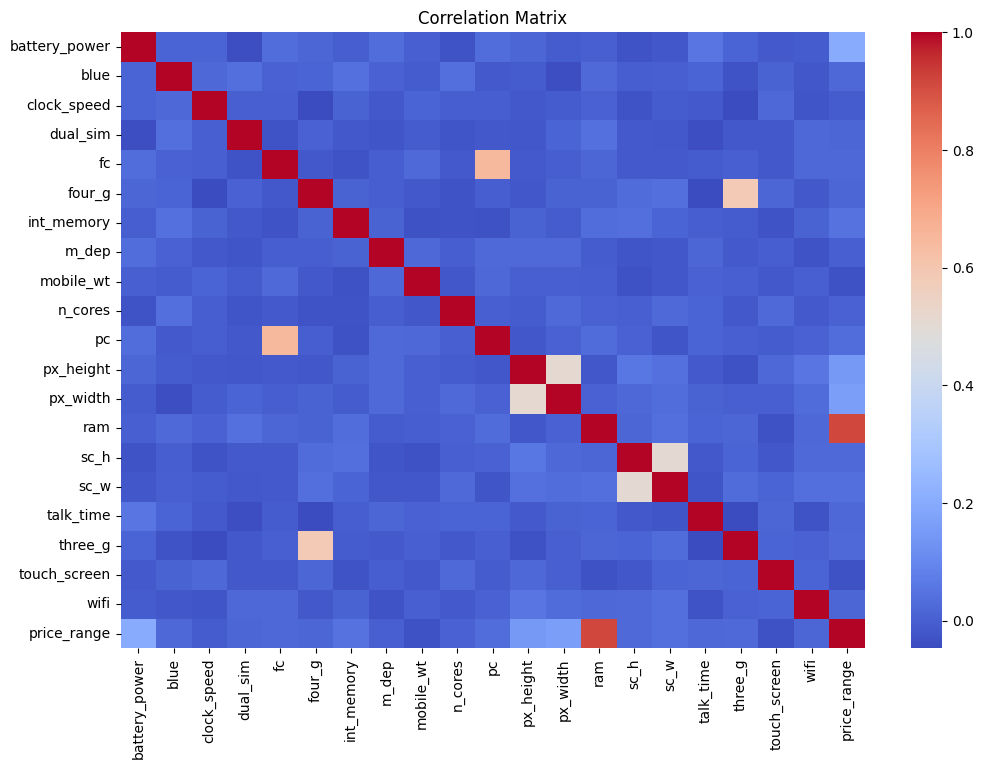

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [16]:
import numpy as np
from scipy import stats

print("=== ANALYSE STATISTIQUE ===")

print("Moyenne RAM :", np.mean(df['ram']))
print("Médiane RAM :", np.median(df['ram']))
print("Variance RAM :", np.var(df['ram']))
print("Écart-type RAM :", np.std(df['ram']))

print("Asymétrie (Skewness) :", stats.skew(df['ram']))
print("Kurtosis :", stats.kurtosis(df['ram']))

=== ANALYSE STATISTIQUE ===
Moyenne RAM : 2124.213
Médiane RAM : 2146.5
Variance RAM : 1176055.2846309997
Écart-type RAM : 1084.4608266926932
Asymétrie (Skewness) : 0.006623063336208135
Kurtosis : -1.1919338732410705


In [17]:
corr = df.corr(numeric_only=True)['price_range']
corr = corr.sort_values(ascending=False)

print(corr)

price_range      1.000000
ram              0.917046
battery_power    0.200723
px_width         0.165818
px_height        0.148858
int_memory       0.044435
sc_w             0.038711
pc               0.033599
three_g          0.023611
sc_h             0.022986
fc               0.021998
talk_time        0.021859
blue             0.020573
wifi             0.018785
dual_sim         0.017444
four_g           0.014772
n_cores          0.004399
m_dep            0.000853
clock_speed     -0.006606
mobile_wt       -0.030302
touch_screen    -0.030411
Name: price_range, dtype: float64


In [18]:
from scipy.stats import ttest_ind

low_price = df[df['price_range'] == 0]['ram']
high_price = df[df['price_range'] == 3]['ram']

t_stat, p_value = ttest_ind(low_price, high_price)

print("T-statistic :", t_stat)
print("P-value :", p_value)

if p_value < 0.05:
    print("Différence significative")
else:
    print("Pas de différence significative")

T-statistic : -111.37307717748769
P-value : 0.0
Différence significative


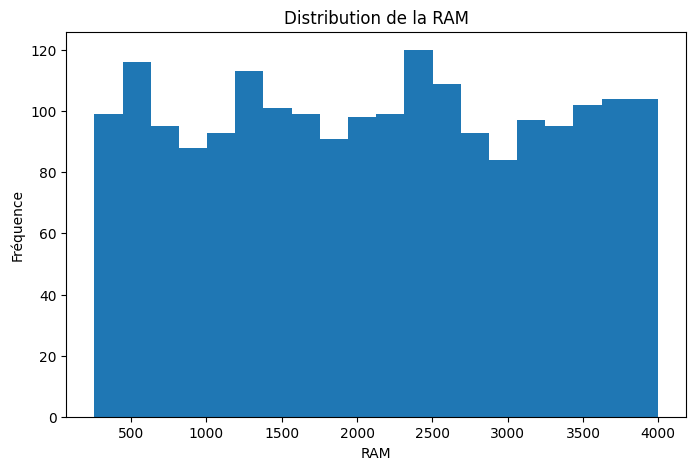

In [19]:
plt.figure(figsize=(8,5))

plt.hist(df['ram'], bins=20)

plt.title('Distribution de la RAM')
plt.xlabel('RAM')
plt.ylabel('Fréquence')

plt.show()

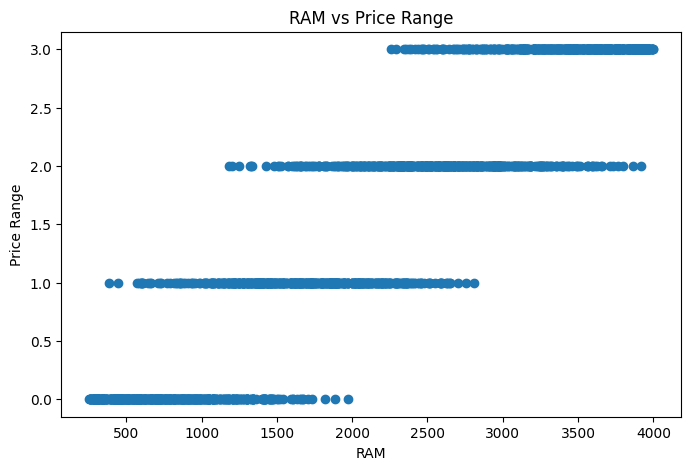

In [20]:
plt.figure(figsize=(8,5))

plt.scatter(df['ram'], df['price_range'])

plt.xlabel('RAM')
plt.ylabel('Price Range')
plt.title('RAM vs Price Range')

plt.show()

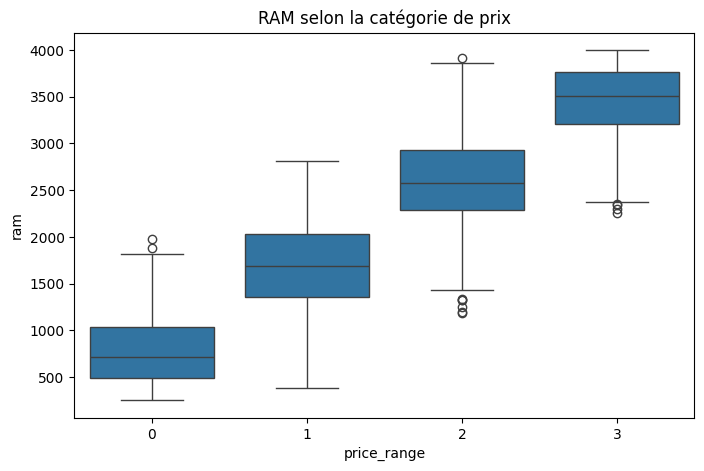

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='price_range',
    y='ram',
    data=df
)

plt.title('RAM selon la catégorie de prix')

plt.show()

In [22]:
print("=== EXECUTIVE SUMMARY ===")

print("Nombre d'observations :", len(df))

print("RAM moyenne :", round(np.mean(df['ram']),2))

print("Prix moyen :", round(np.mean(df['price_range']),2))

print("Corrélation RAM-Prix :",
      round(df['ram'].corr(df['price_range']),3))

print("\nConclusions :")
print("- La RAM est le facteur le plus important.")
print("- Les téléphones haut de gamme possèdent davantage de RAM.")
print("- Les caractéristiques techniques influencent fortement le prix.")

=== EXECUTIVE SUMMARY ===
Nombre d'observations : 2000
RAM moyenne : 2124.21
Prix moyen : 1.5
Corrélation RAM-Prix : 0.917

Conclusions :
- La RAM est le facteur le plus important.
- Les téléphones haut de gamme possèdent davantage de RAM.
- Les caractéristiques techniques influencent fortement le prix.


# Analyse complète des prix des téléphones mobiles

## Objectif

L'objectif de ce projet est d'analyser les caractéristiques techniques des téléphones mobiles et d'identifier les facteurs qui influencent leur catégorie de prix.

Les analyses ont été réalisées à l'aide de :
- NumPy
- Pandas
- SciPy
- Matplotlib
- Seaborn

## 1. Chargement et exploration des données

Dans cette étape, nous chargeons le jeu de données et examinons sa structure générale afin de comprendre les variables disponibles.

## 2. Exploration des données

Nous analysons les types de données, les statistiques descriptives et la présence éventuelle de valeurs manquantes.

## 3. Analyse statistique

Cette section présente les mesures statistiques principales telles que la moyenne, la médiane, la variance et l'écart-type. Nous examinons également la forme de la distribution à l'aide de l'asymétrie (skewness) et de la kurtosis.

## 4. Analyse des corrélations

L'objectif est d'identifier les caractéristiques qui influencent le plus la catégorie de prix des téléphones.

## 5. Test d'hypothèse

Nous comparons les téléphones d'entrée de gamme et les téléphones haut de gamme afin de vérifier si leurs caractéristiques diffèrent de manière statistiquement significative.

## 6. Visualisation des données

Les graphiques permettent de mieux comprendre les distributions des variables ainsi que les relations entre les caractéristiques techniques et le prix.

# Conclusion

Cette analyse a permis d'explorer en détail les caractéristiques techniques des téléphones mobiles.

Les principales observations sont les suivantes :

- La RAM est l'une des variables les plus fortement associées à la catégorie de prix.
- Les téléphones haut de gamme possèdent généralement des caractéristiques matérielles supérieures.
- Les analyses statistiques et les visualisations confirment l'influence importante des spécifications techniques sur le prix final des appareils.

Grâce à NumPy, Pandas, SciPy et Matplotlib, nous avons pu réaliser une analyse complète et tirer des conclusions pertinentes sur les facteurs déterminants du prix des téléphones mobiles.